In [1]:
# extract
import numpy as np
from numpy import linalg as LA

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

class VGGNet:
    def __init__(self):
        self.input_shape = (224, 224, 3)
        self.weight = 'imagenet'
        self.pooling = 'max'
        self.model = VGG16(weights = self.weight, input_shape = (self.input_shape[0], self.input_shape[1], self.input_shape[2]), pooling = self.pooling, include_top = False)
        self.model.predict(np.zeros((1, 224, 224 , 3)))

    def extract_feat(self, img_path):
        img = image.load_img(img_path, target_size=(self.input_shape[0], self.input_shape[1]))
        img = image.img_to_array(img)
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)
        feat = self.model.predict(img)
        norm_feat = feat[0]/LA.norm(feat[0])
        return norm_feat

# model = VGG16(weights = 'imagenet',
#               input_shape = ((224, 224, 3)),
#               pooling = 'max',
#               include_top = False)
# model.summary()


In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
base_path = "/content/gdrive/MyDrive/ml/train+vali/"

Mounted at /content/gdrive


In [3]:
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
from scipy import spatial

In [4]:
h5f = h5py.File("/content/gdrive/MyDrive/ml/vggNotFinetune/VGG16Features.h5", 'r')
feats = h5f['dataset_1'][:]
imgNames = h5f['dataset_2'][:]
h5f.close()

model = VGGNet()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 966ms/step
/content/gdrive/MyDrive/ml/train+vali/Santorini/171.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/85.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/32.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/132.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/60.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/10.2017-08-13_lif_33591955_I1.JPG
/content/gdrive/MyDrive/ml/train+vali/Santorini/142.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/114.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/175.jpg
/content/gdrive/MyDrive/ml/train+vali/Santorini/15.jpg


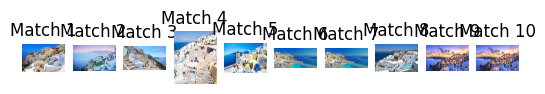

In [6]:
queryImg = "171.jpg"
X = model.extract_feat(queryImg)

scores = []
for i in range(feats.shape[0]):
    score = 1 - spatial.distance.cosine(X, feats[i])
    scores.append(score)
scores = np.array(scores)

rank_ID = np.argsort(scores)[::-1]
rank_score = scores[rank_ID]

maxres = 10
imlist = [imgNames[index].decode('utf-8') for index in rank_ID[0:maxres]]

for i, img_name in enumerate(imlist):
    img_path = os.path.join(base_path, img_name)
    print(img_path)
    img = plt.imread(img_path)
    plt.subplot(1, maxres, i+1)
    plt.imshow(img)
    plt.title(f"Match {i+1}")
    plt.axis('off')
plt.show()